In [18]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("GOOGLE_API_KEY")

In [19]:
# print("Key loaded:", api_key is not None)

In [20]:
# from google import genai
# from dotenv import load_dotenv
# import os

# load_dotenv()
# client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

# for model in client.models.list():
#     print(model.name)

In [21]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict , Optional

In [22]:
class EssaySchema(TypedDict):
    essay_text: str
    clarity_score: Optional[int]
    depth_score: Optional[int]
    feedback: Optional[str]
    average_score: Optional[float]
    detailed_suggestions: Optional[str]

In [23]:
from google import genai
from dotenv import load_dotenv
import os
load_dotenv()
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

In [24]:
from pydantic import BaseModel
class EssayEvaluation(BaseModel):
    clarity_score: int
    depth_score: int
    feedback: str

In [25]:
def evaluate_essay_node(state: EssaySchema) -> dict:
    essay_text = state["essay_text"]
    prompt = f"Evaluate this essay for clarity and depth, each scored out of 10, and give short feedback:\n\n{essay_text}"

    response = client.models.generate_content(
        model="gemma-4-26b-a4b-it",
        contents=prompt,
        config={
            "response_mime_type": "application/json",
            "response_schema": EssayEvaluation,
        },
    )

    result = response.parsed
    avg = (result.clarity_score + result.depth_score) / 2

    return {
        "clarity_score": result.clarity_score,
        "depth_score": result.depth_score,
        "feedback": result.feedback,
        "average_score": avg
    }

In [26]:
def generate_suggestions_node(state: EssaySchema) -> dict:
    essay_text = state['essay_text']
    existing_feedback = state['feedback']
    prompt = f"""This essay: {essay_text} 
    was already noted as weak with this feedback: {existing_feedback}.
    Give 3 specific, actionable suggestions to improve clarity and depth."""
    response = client.models.generate_content(
            model="gemma-4-26b-a4b-it",
            contents=prompt
        )
    suggestion_text = response.text

    return {"detailed_suggestions":suggestion_text}


In [27]:
def route_after_evaluation(state: EssaySchema) -> str:
    if state['average_score'] > 6:
        return "no improvement needed"
    else:
        return "need improvement"


In [28]:
graph = StateGraph(EssaySchema)

In [29]:
# graph.add_conditional_edges(
#     "evaluate_essay",
#     route_after_evaluation,
#     {
#         "no improvement needed": END,
#         "need improvement": "generate_suggestions"
#     }
# )

In [30]:
graph.add_node("evaluate_essay", evaluate_essay_node)
graph.add_node("generate_suggestions", generate_suggestions_node)

graph.add_edge(START, "evaluate_essay")

graph.add_conditional_edges(
    "evaluate_essay",
    route_after_evaluation,
    {
        "no improvement needed": END,
        "need improvement": "generate_suggestions"
    }
)

graph.add_edge("generate_suggestions", END)

app = graph.compile()

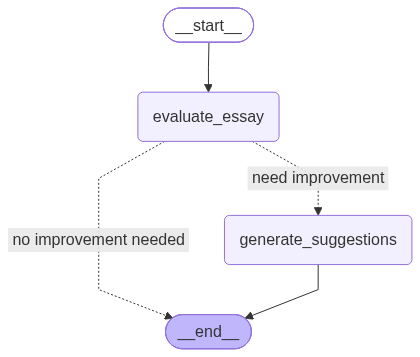

In [31]:
app

In [32]:
weak_essay ="Technology have changed the way people live today. Many peoples use phones and computers everyday for work and communication. It is very useful and helpful in many ways. Overall, technology is good and important for the modern world."

strong_essay = "Reading fiction regularly improves empathy by exposing readers to perspectives different from their own. For example, studies on theory of mind have found that people who read literary fiction perform better at inferring others' emotions and intentions. This effect likely occurs because narrative fiction requires readers to track multiple characters' internal states simultaneously, exercising the same cognitive skills used in real social interaction. As a result, regular fiction reading may serve as a low-cost, accessible way to strengthen social cognition over time."

In [33]:
result_low = app.invoke({"essay_text": weak_essay})
print(result_low)

{'essay_text': 'Technology have changed the way people live today. Many peoples use phones and computers everyday for work and communication. It is very useful and helpful in many ways. Overall, technology is good and important for the modern world.', 'clarity_score': 4, 'depth_score': 2, 'feedback': "The essay is clear in its basic message, but the language is grammatically incorrect in several places (e.g., 'Technology have' and 'Many peoples'). It also lacks depth as the topic is very broad and the lacks the specific details, examples, or arguments to support its claims.", 'average_score': 3.0, 'detailed_suggestions': 'To improve this essay, you need to move from making **general statements** to providing **specific evidence**. Here are three actionable suggestions to improve both the clarity (grammar/structure) and the depth (content/argument):\n\n### 1. Fix Subject-Verb Agreement and Noun Usage (Clarity)\nThe most immediate way to improve clarity is to correct the foundational gra

In [34]:
result_high = app.invoke({"essay_text": strong_essay})
print(result_high)

{'essay_text': "Reading fiction regularly improves empathy by exposing readers to perspectives different from their own. For example, studies on theory of mind have found that people who read literary fiction perform better at inferring others' emotions and intentions. This effect likely occurs because narrative fiction requires readers to track multiple characters' internal states simultaneously, exercising the same cognitive skills used in real social interaction. As a result, regular fiction reading may serve as a low-cost, accessible way to strengthen social cognition over time.", 'clarity_score': 10, 'depth_score': 8, 'feedback': 'The essay is exceptionally clear and concise, using logical transitions and evidence-based reasoning to explain the mechanism of cognitive benefits. The depth is strong, though a brief mention of different genres or the weight of different narrative complexity might have added more nuance to the specific claim.', 'average_score': 9.0}
